In [1]:
import sys

sys.path.append("../")

import scipy

import numpy as np

from qiskit.circuit import ClassicalRegister, Parameter, QuantumCircuit, QuantumRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

from dicke_state_ansatz import DickeStateAnsatz

In [2]:
simulator = AerSimulator(method="statevector", device="GPU")
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)

In [3]:
n = 4

$\vert \psi(\vec{\alpha}, \vec{\theta})\rangle = \sum_{k=k_{\textrm{min}}}^{k_{\textrm{max}}+1}\sqrt{p_k(\vec{\alpha})}\vert D_k^n(\vec{\theta}) \rangle\otimes\vert k \rangle$

$\rho_{AB}(\vec{\alpha}, \vec{\theta}) = \sum_{k=k_{\textrm{min}}}^{k_{\textrm{max}}+1}\sum_{l=k_{\textrm{min}}}^{k_{\textrm{max}}+1}\sqrt{p_k(\vec{\alpha})}\sqrt{p_l(\vec{\alpha})}\vert D_k^n(\vec{\theta}) \rangle \langle D_l^n(\vec{\theta}) \vert \otimes \vert k \rangle \langle l \vert$

$\rho_A(\vec{\alpha}, \vec{\theta}) = \textrm{tr}_B(\rho_{AB}(\vec{\alpha}, \vec{\theta}))$

$\rho_A(\vec{\alpha}, \vec{\theta}) = \sum_{k=k_{\textrm{min}}}^{k_{\textrm{max}}+1}p_k(\vec{\alpha})\vert D_k^n(\vec{\theta}) \rangle \langle D_k^n(\vec{\theta}) \vert$

$\langle H \rangle = \textrm{tr}(\rho_A(\vec{\alpha}, \vec{\theta})H); H = \sum_iE_i\vert i \rangle\langle i \vert$

$\langle H \rangle = \sum_iE_i\rho_{ii}(\vec{\alpha}, \vec{\theta})$

$\min_{\vec{\alpha}, \vec{\theta} \in \mathbb{R}} \textrm{tr}(\rho_A(\vec{\alpha}, \vec{\theta})H)$

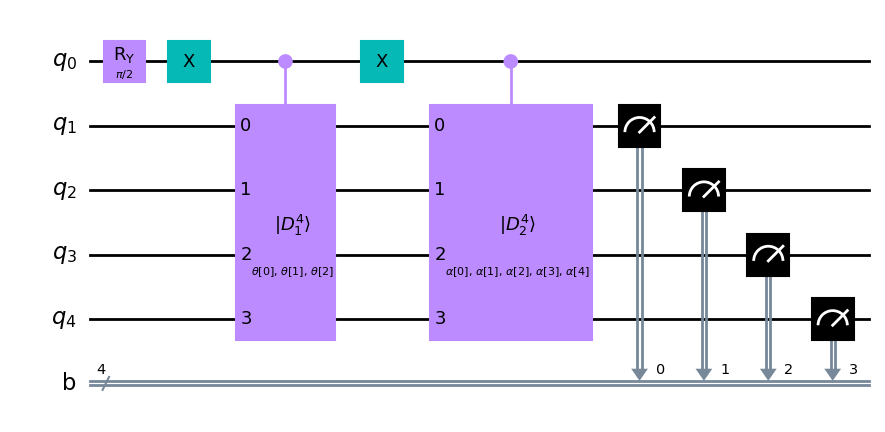

In [4]:
qubits = QuantumRegister(size=5, name="q")
bits = ClassicalRegister(size=n, name="b")

qc = QuantumCircuit(qubits, bits)
qc.ry(theta=np.pi/2, qubit=qubits[0])

params_names = {1: "theta", 2: "alpha"}

for k in range(1,3):
    dicke = DickeStateAnsatz().generate_quantum_circuit(n=n, k=k, measurement=False, param_name=params_names[k])
    if k == 1:
        qc.x(qubit=qubits[0])
    dicke_gate = dicke.to_gate(label=rf"$\vert D^{n}_{k} \rangle$").control(1)
    qc.append(dicke_gate, qargs=range(qubits.size))
    if k == 1:
        qc.x(qubit=qubits[0])

qc.measure(qubit=qubits[1:], cbit=bits)
qc.draw(output="mpl", style="clifford")

In [5]:
params_mapping = {param: np.pi/2 for param in qc.parameters}
qc = qc.assign_parameters(parameters=params_mapping)

In [6]:
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)
tqc = pm.run(qc)

In [7]:
counts = simulator.run(circuits=tqc, shots=4096).result().get_counts()

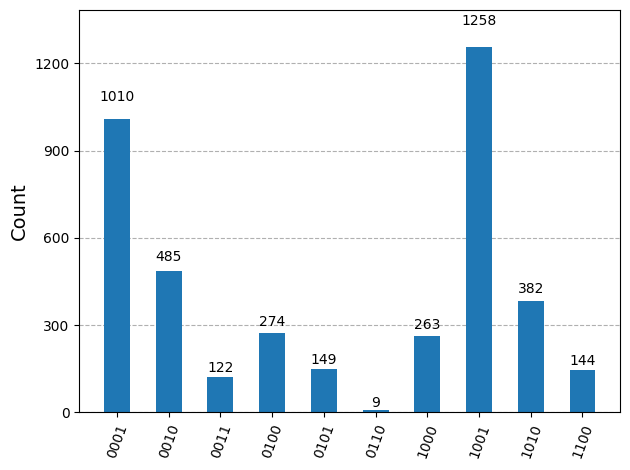

In [8]:
plot_histogram(data=counts)